In [2]:
import numpy as np
import pandas as pd

# 1. Load the dataset
# Replace 'path_to_your_dataset.csv' with your actual filename or path
df = pd.read_csv("EEG.machinelearing_data_BRMH.csv")
print(f"Initial shape of the dataset: {df.shape}")

# 2. Fix the typo in specific.disorder
df["specific.disorder"] = df["specific.disorder"].replace(
    {"Obsessive compulsitve disorder": "Obsessive compulsive disorder"}
)

# 3. Drop unneeded metadata columns
columns_to_drop = ["no.", "eeg.date"]
# Using errors='ignore' ensures it won't crash if they were already removed
df = df.drop(columns=columns_to_drop, errors="ignore")

# 4. Handle Missing Values (IQ and education)
# We impute using the median value of their respective main.disorder group
print("\nMissing values before imputation:")
print(df[["education", "IQ"]].isnull().sum())

df["education"] = df.groupby("main.disorder")["education"].transform(
    lambda x: x.fillna(x.median())
)
df["IQ"] = df.groupby("main.disorder")["IQ"].transform(
    lambda x: x.fillna(x.median())
)

print("\nMissing values after imputation:")
print(df[["education", "IQ"]].isnull().sum())
print(f"\nFinal shape after Step 1: {df.shape}")

Initial shape of the dataset: (945, 1149)

Missing values before imputation:
education    15
IQ           13
dtype: int64

Missing values after imputation:
education    0
IQ           0
dtype: int64

Final shape after Step 1: (945, 1147)


In [3]:
from sklearn.preprocessing import LabelEncoder

# 1. Separate features and targets
# We're making copies to avoid any setting-with-copy warnings later
X = df.drop(columns=["main.disorder", "specific.disorder"]).copy()

# Store the targets separately
y_main = df["main.disorder"].copy()
y_specific = df["specific.disorder"].copy()

# 2. Binary encode the 'sex' column (M -> 1, F -> 0)
X["sex"] = X["sex"].map({"M": 1, "F": 0})

# 3. Label encode the target variables
le_main = LabelEncoder()
y_main_encoded = le_main.fit_transform(y_main)

le_specific = LabelEncoder()
y_specific_encoded = le_specific.fit_transform(y_specific)

# 4. Verify the mappings
print("--- Target Mapping Verification ---")
for i, item in enumerate(le_main.classes_):
    print(f"Main Disorder: {item} -> Encoded Label: {i}")

print(f"\nFeatures shape (X): {X.shape}")
print(f"Target shape (y_main_encoded): {y_main_encoded.shape}")

# Double check that we don't have any non-numeric data left in X
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nRemaining non-numeric columns in X: {non_numeric_cols}")

--- Target Mapping Verification ---
Main Disorder: Addictive disorder -> Encoded Label: 0
Main Disorder: Anxiety disorder -> Encoded Label: 1
Main Disorder: Healthy control -> Encoded Label: 2
Main Disorder: Mood disorder -> Encoded Label: 3
Main Disorder: Obsessive compulsive disorder -> Encoded Label: 4
Main Disorder: Schizophrenia -> Encoded Label: 5
Main Disorder: Trauma and stress related disorder -> Encoded Label: 6

Features shape (X): (945, 1145)
Target shape (y_main_encoded): (945,)

Remaining non-numeric columns in X: []


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. First split: Separate the 15% Test set from the rest (85%)
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X, 
    y_main_encoded, 
    test_size=0.15, 
    random_state=42, 
    stratify=y_main_encoded
)

# 2. Second split: Divide the remaining 85% into Train (70% total) and Validation (15% total)
# 0.1765 is roughly 15% of the original 100% (0.15 / 0.85)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.1765, 
    random_state=42, 
    stratify=y_temp
)

# 3. Scale the features carefully to prevent data leakage
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train_raw)

# Transform validation and test data using the training setup
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Convert back to DataFrames for easy feature tracking
X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

# 4. Output verification
print(f"Train set shape:      {X_train.shape}, Target: {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, Target: {y_val.shape}")
print(f"Test set shape:       {X_test.shape}, Target: {y_test.shape}")

print("\nDisorder distribution in Validation Set (Class Labels):")
print(np.bincount(y_val))


Train set shape:      (661, 1145), Target: (661,)
Validation set shape: (142, 1145), Target: (142,)
Test set shape:       (142, 1145), Target: (142,)

Disorder distribution in Validation Set (Class Labels):
[28 16 14 40  7 18 19]


C:\Users\Rochan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\Rochan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\Rochan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [6]:
# Check for NaNs across the data splits
nan_train = X_train.isnull().sum().sum()
nan_val = X_val.isnull().sum().sum()
nan_test = X_test.isnull().sum().sum()

print(f"Total NaNs in Train Set: {nan_train}")
print(f"Total NaNs in Val Set:   {nan_val}")
print(f"Total NaNs in Test Set:  {nan_test}")

# If there are NaNs, let's see which specific columns they are in
if nan_train > 0:
    nan_cols = X_train.columns[X_train.isnull().any()].tolist()
    print(f"\nColumns with NaNs in Train Set (Top 5): {nan_cols[:5]}")
    
    # Check if these columns have zero variance in the raw data (which causes divide-by-zero during scaling)
    print("\nChecking raw standard deviation of these bad columns:")
    print(X_train_raw[nan_cols[:5]].std())
    

Total NaNs in Train Set: 661
Total NaNs in Val Set:   142
Total NaNs in Test Set:  142

Columns with NaNs in Train Set (Top 5): ['Unnamed: 122']

Checking raw standard deviation of these bad columns:
Unnamed: 122   NaN
dtype: float64


In [7]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Safely drop the problematic column from all splits if it exists
columns_to_drop = ["Unnamed: 122"]
X_train = X_train.drop(columns=columns_to_drop, errors="ignore")
X_val = X_val.drop(columns=columns_to_drop, errors="ignore")
X_test = X_test.drop(columns=columns_to_drop, errors="ignore")

print(f"New feature matrix shape after dropping artifact: {X_train.shape}")

# 2. Re-initialize Logistic Regression with L1 penalty (Lasso)
baseline_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    random_state=42,
    class_weight="balanced",
)

# 3. Fit the model on the training data
baseline_model.fit(X_train, y_train)

# 4. Calculate feature importance (how many weights are non-zero)
coefficients = baseline_model.coef_
active_features_mask = np.any(coefficients != 0, axis=0)
num_active_features = np.sum(active_features_mask)

print(f"\n--- Feature Selection Results ---")
print(f"Original number of features: {X_train.shape[1]}")
print(f"Features kept by L1 Regularization: {num_active_features}")
print(
    f"Features eliminated (dropped to 0): {X_train.shape[1] - num_active_features}"
)

# 5. Evaluate on the Validation Set
y_val_pred = baseline_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"\n--- Validation Performance ---")
print(f"Validation Accuracy: {val_accuracy:.4f}\n")
print(
    classification_report(y_val, y_val_pred, target_names=le_main.classes_)
)

New feature matrix shape after dropping artifact: (661, 1144)

--- Feature Selection Results ---
Original number of features: 1144
Features kept by L1 Regularization: 185
Features eliminated (dropped to 0): 959

--- Validation Performance ---
Validation Accuracy: 0.3028

                                    precision    recall  f1-score   support

                Addictive disorder       0.38      0.46      0.42        28
                  Anxiety disorder       0.14      0.19      0.16        16
                   Healthy control       0.33      0.50      0.40        14
                     Mood disorder       0.30      0.17      0.22        40
     Obsessive compulsive disorder       0.10      0.14      0.12         7
                     Schizophrenia       0.25      0.22      0.24        18
Trauma and stress related disorder       0.47      0.42      0.44        19

                          accuracy                           0.30       142
                         macro avg       0

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize Random Forest
# We restrict max_depth and min_samples_leaf to prevent it from overfitting 
# to the 1144 features.
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. Fit the model on the training data
rf_model.fit(X_train, y_train)

# 3. Evaluate on the Training Set (to check for overfitting)
y_train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# 4. Evaluate on the Validation Set
y_val_pred_rf = rf_model.predict(X_val)
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)

print(f"--- Random Forest Performance ---")
print(f"Training Accuracy:   {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy_rf:.4f}\n")

print(classification_report(y_val, y_val_pred_rf, target_names=le_main.classes_))

--- Random Forest Performance ---
Training Accuracy:   1.0000
Validation Accuracy: 0.2958

                                    precision    recall  f1-score   support

                Addictive disorder       0.37      0.46      0.41        28
                  Anxiety disorder       0.12      0.06      0.08        16
                   Healthy control       0.20      0.14      0.17        14
                     Mood disorder       0.27      0.50      0.35        40
     Obsessive compulsive disorder       0.25      0.14      0.18         7
                     Schizophrenia       0.00      0.00      0.00        18
Trauma and stress related disorder       0.50      0.26      0.34        19

                          accuracy                           0.30       142
                         macro avg       0.25      0.23      0.22       142
                      weighted avg       0.26      0.30      0.26       142



In [9]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Use the active features mask from Step 4 to filter columns
# active_features_mask was created from our baseline_model.coef_
X_train_selected = X_train.iloc[:, active_features_mask]
X_val_selected = X_val.iloc[:, active_features_mask]

print(f"Old feature count: {X_train.shape[1]}")
print(f"New feature count for Random Forest: {X_train_selected.shape[1]}")

# 2. Re-initialize Random Forest with much stricter regularization
# We lower max_depth and increase min_samples_leaf to aggressively fight overfitting
rf_selected_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,  # Shorter trees = less overfitting
    min_samples_leaf=5,  # Requires more samples to make a rule
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

# 3. Fit the model on the REDUCED feature set
rf_selected_model.fit(X_train_selected, y_train)

# 4. Evaluate to see if we closed the overfitting gap
y_train_pred = rf_selected_model.predict(X_train_selected)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_val_pred_rf = rf_selected_model.predict(X_val_selected)
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)

print(f"\n--- Regularized Random Forest Performance ---")
print(f"Training Accuracy:   {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy_rf:.4f}\n")

print(
    classification_report(y_val, y_val_pred_rf, target_names=le_main.classes_)
)

Old feature count: 1144
New feature count for Random Forest: 185

--- Regularized Random Forest Performance ---
Training Accuracy:   0.9077
Validation Accuracy: 0.2606

                                    precision    recall  f1-score   support

                Addictive disorder       0.41      0.46      0.43        28
                  Anxiety disorder       0.08      0.12      0.10        16
                   Healthy control       0.41      0.50      0.45        14
                     Mood disorder       0.29      0.17      0.22        40
     Obsessive compulsive disorder       0.14      0.14      0.14         7
                     Schizophrenia       0.10      0.11      0.10        18
Trauma and stress related disorder       0.29      0.26      0.28        19

                          accuracy                           0.26       142
                         macro avg       0.25      0.25      0.25       142
                      weighted avg       0.27      0.26      0.26    

In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize the Neural Network (MLP)
# hidden_layer_sizes=(128, 64) matches our design
# alpha=0.05 is the L2 weight regularization penalty (higher = less overfitting)
# early_stopping=True acts like Dropout by halting training before it overfits
nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.05,  # L2 Regularization parameter
    batch_size=32,
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,  # Monitors internal validation to stop early
    validation_fraction=0.15,
    random_state=42,
    verbose=False,
)

# 2. Fit the model on our selected 185 features
nn_model.fit(X_train_selected, y_train)

# 3. Evaluate on Training set
y_train_pred_nn = nn_model.predict(X_train_selected)
train_accuracy_nn = accuracy_score(y_train, y_train_pred_nn)

# 4. Evaluate on your explicit Validation set
y_val_pred_nn = nn_model.predict(X_val_selected)
val_accuracy_nn = accuracy_score(y_val, y_val_pred_nn)

print(f"--- Neural Network Performance ---")
print(f"Training Accuracy:   {train_accuracy_nn:.4f}")
print(f"Validation Accuracy: {val_accuracy_nn:.4f}\n")

print(
    classification_report(y_val, y_val_pred_nn, target_names=le_main.classes_)
)

--- Neural Network Performance ---
Training Accuracy:   0.9032
Validation Accuracy: 0.3239

                                    precision    recall  f1-score   support

                Addictive disorder       0.40      0.43      0.41        28
                  Anxiety disorder       0.09      0.06      0.07        16
                   Healthy control       0.27      0.29      0.28        14
                     Mood disorder       0.37      0.47      0.42        40
     Obsessive compulsive disorder       0.25      0.14      0.18         7
                     Schizophrenia       0.24      0.22      0.23        18
Trauma and stress related disorder       0.36      0.26      0.30        19

                          accuracy                           0.32       142
                         macro avg       0.28      0.27      0.27       142
                      weighted avg       0.31      0.32      0.31       142



# HHHHHHHHHHHHHHHHHHH

In [12]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 2 is the encoded label for 'Healthy control' based on Step 2 verification
HEALTHY_LABEL = 2

# 1. Map the multi-class targets to binary targets (0: Healthy, 1: Patient)
y_train_binary = np.where(y_train == HEALTHY_LABEL, 0, 1)
y_val_binary = np.where(y_val == HEALTHY_LABEL, 0, 1)

print("--- Binary Label Counts ---")
print(f"Train - Healthy (0): {np.sum(y_train_binary == 0)}, Patient (1): {np.sum(y_train_binary == 1)}")
print(f"Val   - Healthy (0): {np.sum(y_val_binary == 0)}, Patient (1): {np.sum(y_val_binary == 1)}")

# 2. Retrain our Neural Network on this binary problem
nn_binary = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.1,  # Slightly increased regularization for sturdier rules
    batch_size=32,
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
    verbose=False,
)

nn_binary.fit(X_train_selected, y_train_binary)

# 3. Predict and evaluate
y_train_pred_bin = nn_binary.predict(X_train_selected)
y_val_pred_bin = nn_binary.predict(X_val_selected)

print(f"\n--- Binary Neural Network Performance ---")
print(f"Training Accuracy:   {accuracy_score(y_train_binary, y_train_pred_bin):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val_binary, y_val_pred_bin):.4f}\n")

print(
    classification_report(
        y_val_binary, y_val_pred_bin, target_names=["Healthy Control", "Patient"]
    )
)

--- Binary Label Counts ---
Train - Healthy (0): 67, Patient (1): 594
Val   - Healthy (0): 14, Patient (1): 128

--- Binary Neural Network Performance ---
Training Accuracy:   0.9486
Validation Accuracy: 0.9085

                 precision    recall  f1-score   support

Healthy Control       0.60      0.21      0.32        14
        Patient       0.92      0.98      0.95       128

       accuracy                           0.91       142
      macro avg       0.76      0.60      0.63       142
   weighted avg       0.89      0.91      0.89       142



In [13]:
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Apply SMOTE ONLY to the training data to prevent leakage
# This will synthetically generate more 'Healthy Control' samples so it matches 'Patient'
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_selected, y_train_binary)

print("--- Balanced Training Label Counts ---")
print(f"Original Train - Healthy: {np.sum(y_train_binary == 0)}, Patient: {np.sum(y_train_binary == 1)}")
print(f"SMOTE Train    - Healthy: {np.sum(y_train_balanced == 0)}, Patient: {np.sum(y_train_balanced == 1)}")

# 2. Retrain our Neural Network on the balanced dataset
# We use a lower learning rate and higher regularization to account for the generated data
nn_balanced = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.5,  # Increased regularization to avoid overfitting synthetic data
    batch_size=32,
    learning_rate_init=0.0005,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
    verbose=False,
)

nn_balanced.fit(X_train_balanced, y_train_balanced)

# 3. Predict and evaluate
y_val_pred_bal = nn_balanced.predict(X_val_selected)

print(f"\n--- Balanced Binary Neural Network Performance ---")
print(f"Validation Accuracy: {accuracy_score(y_val_binary, y_val_pred_bal):.4f}\n")

print(
    classification_report(
        y_val_binary, y_val_pred_bal, target_names=["Healthy Control", "Patient"]
    )
)

C:\Users\Rochan\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


--- Balanced Training Label Counts ---
Original Train - Healthy: 67, Patient: 594
SMOTE Train    - Healthy: 594, Patient: 594

--- Balanced Binary Neural Network Performance ---
Validation Accuracy: 0.8662

                 precision    recall  f1-score   support

Healthy Control       0.22      0.14      0.17        14
        Patient       0.91      0.95      0.93       128

       accuracy                           0.87       142
      macro avg       0.57      0.54      0.55       142
   weighted avg       0.84      0.87      0.85       142



In [14]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 1. Get raw probability predictions for the validation set using our Step 8 model (nn_binary)
# This gives two columns: [Probability of Healthy, Probability of Patient]
val_probabilities = nn_binary.predict_proba(X_val_selected)

# 2. Lower the threshold for predicting "Healthy"
# Normally it's 0.50. Let's say if the model is even 15% sure someone is Healthy, we classify them as Healthy.
# (Patient probability has to be greater than 0.85 to be called a Patient)
custom_threshold = 0.85
y_val_pred_tuned = np.where(val_probabilities[:, 1] > custom_threshold, 1, 0)

print(f"--- Tuned Threshold Performance (Patient Threshold: {custom_threshold}) ---")
print(f"Validation Accuracy: {accuracy_score(y_val_binary, y_val_pred_tuned):.4f}\n")

print(
    classification_report(
        y_val_binary, y_val_pred_tuned, target_names=["Healthy Control", "Patient"]
    )
)


--- Tuned Threshold Performance (Patient Threshold: 0.85) ---
Validation Accuracy: 0.7535

                 precision    recall  f1-score   support

Healthy Control       0.20      0.50      0.29        14
        Patient       0.93      0.78      0.85       128

       accuracy                           0.75       142
      macro avg       0.57      0.64      0.57       142
   weighted avg       0.86      0.75      0.80       142



In [16]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Filter out Healthy Controls (Label 2) from our data splits
patient_train_mask = (y_train != 2)
patient_val_mask = (y_val != 2)

X_train_patients = X_train_selected[patient_train_mask]
y_train_patients = y_train[patient_train_mask]

X_val_patients = X_val_selected[patient_val_mask]
y_val_patients = y_val[patient_val_mask]

# Get the names of the remaining 6 clinical disorders
patient_classes = [name for i, name in enumerate(le_main.classes_) if i != 2]

print("--- Patient-Only Data Split ---")
print(f"Train samples (Patients only): {X_train_patients.shape[0]}")
print(f"Val samples (Patients only):   {X_val_patients.shape[0]}")
print(f"Remaining target classes:      {patient_classes}")

# 2. Train a dedicated Neural Network for Differential Diagnosis
nn_patients = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.2,  # Strong L2 regularization to manage the 6-way split
    batch_size=32,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
    verbose=False
)

nn_patients.fit(X_train_patients, y_train_patients)

# 3. Evaluate on Patient Validation data
y_val_pred_pat = nn_patients.predict(X_val_patients)

print(f"\n--- Patient-Only Differential Performance ---")
print(f"Validation Accuracy: {accuracy_score(y_val_patients, y_val_pred_pat):.4f}\n")

print(
    classification_report(
        y_val_patients, y_val_pred_pat, target_names=patient_classes
    )
)

--- Patient-Only Data Split ---
Train samples (Patients only): 594
Val samples (Patients only):   128
Remaining target classes:      ['Addictive disorder', 'Anxiety disorder', 'Mood disorder', 'Obsessive compulsive disorder', 'Schizophrenia', 'Trauma and stress related disorder']

--- Patient-Only Differential Performance ---
Validation Accuracy: 0.3125

                                    precision    recall  f1-score   support

                Addictive disorder       0.39      0.43      0.41        28
                  Anxiety disorder       0.08      0.06      0.07        16
                     Mood disorder       0.38      0.53      0.44        40
     Obsessive compulsive disorder       0.25      0.14      0.18         7
                     Schizophrenia       0.09      0.06      0.07        18
Trauma and stress related disorder       0.29      0.21      0.24        19

                          accuracy                           0.31       128
                         macro av

In [17]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Define frontal electrodes based on your dataset overview
frontal_electrodes = ['FP1', 'FP2', 'F3', 'F4', 'Fz', 'F7', 'F8']

def add_eeg_ratios(df_raw, df_target):
    """
    Finds the frontal electrode columns for theta, beta, and alpha,
    averages them, and creates clinical biomarker ratios.
    """
    df_new = df_target.copy()
    
    # 1. Gather all frontal columns for each specific band
    # Example column format from your description: AB.A.delta.a.FP1
    theta_cols = [c for c in df_raw.columns if 'AB.' in c and '.theta.' in c and any(e in c for e in frontal_electrodes)]
    beta_cols  = [c for c in df_raw.columns if 'AB.' in c and '.beta.' in c and any(e in c for e in frontal_electrodes)]
    alpha_cols = [c for c in df_raw.columns if 'AB.' in c and '.alpha.' in c and any(e in c for e in frontal_electrodes)]
    
    # 2. Calculate the average absolute power across the frontal lobe
    # We pull from the raw non-scaled dataframe to keep the math ecologically valid
    frontal_theta = df_raw[theta_cols].mean(axis=1)
    frontal_beta  = df_raw[beta_cols].mean(axis=1)
    frontal_alpha = df_raw[alpha_cols].mean(axis=1)
    
    # 3. Add the engineered ratios to our active feature set
    # Adding a small epsilon (1e-6) to prevent divide-by-zero errors
    df_new['Frontal_Theta_Beta_Ratio'] = frontal_theta / (frontal_beta + 1e-6)
    df_new['Frontal_Theta_Alpha_Ratio'] = frontal_theta / (frontal_alpha + 1e-6)
    df_new['Frontal_Alpha_Beta_Ratio'] = frontal_alpha / (frontal_beta + 1e-6)
    
    return df_new

# Apply the feature engineering to Train and Validation sets using the raw data coordinates
X_train_engineered = add_eeg_ratios(X_train_raw.iloc[patient_train_mask], X_train_patients)
X_val_engineered = add_eeg_ratios(X_val_raw.iloc[patient_val_mask], X_val_patients)

print("--- Feature Engineering Results ---")
print(f"Features before ratio engineering: {X_train_patients.shape[1]}")
print(f"Features after ratio engineering:  {X_train_engineered.shape[1]}")
print("\nNew columns added successfully:")
print(X_train_engineered[['Frontal_Theta_Beta_Ratio', 'Frontal_Theta_Alpha_Ratio']].head(3))

--- Feature Engineering Results ---
Features before ratio engineering: 185
Features after ratio engineering:  188

New columns added successfully:
   Frontal_Theta_Beta_Ratio  Frontal_Theta_Alpha_Ratio
0                  1.541243                   0.413077
1                       NaN                        NaN
2                       NaN                        NaN


In [18]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define frontal electrodes based on your dataset overview
frontal_electrodes = ["FP1", "FP2", "F3", "F4", "Fz", "F7", "F8"]


def add_eeg_ratios_fixed(df_raw_subset, df_target_subset):
    """Computes clinical biomarker ratios with clean index resetting to prevent NaNs."""
    df_new = df_target_subset.copy().reset_index(drop=True)
    df_raw_reset = df_raw_subset.copy().reset_index(drop=True)

    # 1. Gather all frontal columns for each specific band
    theta_cols = [
        c
        for c in df_raw_reset.columns
        if "AB." in c
        and ".theta." in c
        and any(e in c for e in frontal_electrodes)
    ]
    beta_cols = [
        c
        for c in df_raw_reset.columns
        if "AB." in c
        and ".beta." in c
        and any(e in c for e in frontal_electrodes)
    ]
    alpha_cols = [
        c
        for c in df_raw_reset.columns
        if "AB." in c
        and ".alpha." in c
        and any(e in c for e in frontal_electrodes)
    ]

    # 2. Calculate the average absolute power across the frontal lobe
    frontal_theta = df_raw_reset[theta_cols].mean(axis=1)
    frontal_beta = df_raw_reset[beta_cols].mean(axis=1)
    frontal_alpha = df_raw_reset[alpha_cols].mean(axis=1)

    # 3. Add the engineered ratios using clear assignment (no mismatching indices)
    df_new["Frontal_Theta_Beta_Ratio"] = frontal_theta / (frontal_beta + 1e-6)
    df_new["Frontal_Theta_Alpha_Ratio"] = frontal_theta / (
        frontal_alpha + 1e-6
    )
    df_new["Frontal_Alpha_Beta_Ratio"] = frontal_alpha / (frontal_beta + 1e-6)

    return df_new


# Re-run with the structural index fixes
X_train_engineered = add_eeg_ratios_fixed(
    X_train_raw.iloc[patient_train_mask], X_train_patients
)
X_val_engineered = add_eeg_ratios_fixed(
    X_val_raw.iloc[patient_val_mask], X_val_patients
)

print("--- Feature Engineering Results ---")
print(f"Features after ratio engineering: {X_train_engineered.shape[1]}")
print(f"Total missing values in new training columns: ")
print(
    X_train_engineered[
        ["Frontal_Theta_Beta_Ratio", "Frontal_Theta_Alpha_Ratio"]
    ]
    .isna()
    .sum()
)

print("\nFirst 3 rows verified:")
print(
    X_train_engineered[
        ["Frontal_Theta_Beta_Ratio", "Frontal_Theta_Alpha_Ratio"]
    ].head(3)
)


--- Feature Engineering Results ---
Features after ratio engineering: 188
Total missing values in new training columns: 
Frontal_Theta_Beta_Ratio     0
Frontal_Theta_Alpha_Ratio    0
dtype: int64

First 3 rows verified:
   Frontal_Theta_Beta_Ratio  Frontal_Theta_Alpha_Ratio
0                  1.560891                   1.327343
1                  2.733994                   3.142570
2                  1.411368                   0.492132


In [20]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# 1. Scale the newly added ratio features
ratio_scaler = StandardScaler()

# Columns to scale are the last 3 we added
ratio_cols = [
    "Frontal_Theta_Beta_Ratio",
    "Frontal_Theta_Alpha_Ratio",
    "Frontal_Alpha_Beta_Ratio",
]

# Create copies to preserve the datasets securely
X_train_final = X_train_engineered.copy()
X_val_final = X_val_engineered.copy()

# Fit and transform on training ratios, transform on validation ratios
X_train_final[ratio_cols] = ratio_scaler.fit_transform(
    X_train_engineered[ratio_cols]
)
X_val_final[ratio_cols] = ratio_scaler.transform(X_val_engineered[ratio_cols])

# 2. Train the Neural Network on the final engineered feature set
nn_differential = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.3,  # Solid regularization to manage the 6 distinct targets
    batch_size=32,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
    verbose=False,
)

# Remember target classes are from Step 11: y_train_patients and y_val_patients
nn_differential.fit(X_train_final, y_train_patients)

# 3. Predict and evaluate
y_val_pred_final = nn_differential.predict(X_val_final)
final_accuracy = accuracy_score(y_val_patients, y_val_pred_final)

print(f"--- Biomarker-Enhanced Multi-Class Performance ---")
print(f"Validation Accuracy: {final_accuracy:.4f}\n")

print(
    classification_report(
        y_val_patients, y_val_pred_final, target_names=patient_classes
    )
)

--- Biomarker-Enhanced Multi-Class Performance ---
Validation Accuracy: 0.2422

                                    precision    recall  f1-score   support

                Addictive disorder       0.16      0.25      0.20        28
                  Anxiety disorder       0.50      0.12      0.20        16
                     Mood disorder       0.28      0.55      0.37        40
     Obsessive compulsive disorder       0.00      0.00      0.00         7
                     Schizophrenia       0.00      0.00      0.00        18
Trauma and stress related disorder       0.00      0.00      0.00        19

                          accuracy                           0.24       128
                         macro avg       0.16      0.15      0.13       128
                      weighted avg       0.19      0.24      0.18       128



C:\Users\Rochan\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Rochan\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Rochan\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [22]:
!pip install lightgbm


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 15.2 MB/s  0:00:00



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize LightGBM with strict regularization to handle the 6-way split
lgb_model = LGBMClassifier(
    n_estimators=150,
    max_depth=4,         # Keep trees shallow to prevent overfitting
    learning_rate=0.03,  # Slow down learning rate for sturdier patterns
    class_weight='balanced',  # Forces it to look at OCD, Schizophrenia, and Trauma
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)

# 2. Fit the model on our engineered features
# We can use X_train_engineered directly since LightGBM doesn't care about scaling
lgb_model.fit(X_train_engineered, y_train_patients)

# 3. Evaluate on Patient Validation data
y_val_pred_lgb = lgb_model.predict(X_val_engineered)
lgb_accuracy = accuracy_score(y_val_patients, y_val_pred_lgb)

print(f"--- LightGBM Multi-Class Performance ---")
print(f"Validation Accuracy: {lgb_accuracy:.4f}\n")

print(classification_report(y_val_patients, y_val_pred_lgb, target_names=patient_classes))

--- LightGBM Multi-Class Performance ---
Validation Accuracy: 0.3125

                                    precision    recall  f1-score   support

                Addictive disorder       0.42      0.46      0.44        28
                  Anxiety disorder       0.08      0.06      0.07        16
                     Mood disorder       0.37      0.40      0.39        40
     Obsessive compulsive disorder       0.25      0.14      0.18         7
                     Schizophrenia       0.14      0.17      0.15        18
Trauma and stress related disorder       0.38      0.32      0.34        19

                          accuracy                           0.31       128
                         macro avg       0.27      0.26      0.26       128
                      weighted avg       0.31      0.31      0.31       128



In [24]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Separate the raw data columns based on their clinical prefix
# df is our cleaned data from Step 1 containing raw columns
patient_raw_df = df[df["main.disorder"] != "Healthy control"].copy().reset_index(drop=True)

# Separate metadata columns from the EEG features
metadata_cols = ["sex", "age", "education", "IQ"]
eeg_cols = [c for c in patient_raw_df.columns if c not in metadata_cols + ["main.disorder", "specific.disorder"]]

coh_cols = [c for c in eeg_cols if "COH." in c]
ab_cols = [c for c in eeg_cols if "AB." in c]

print("--- Data Restructuring Overview ---")
print(f"Total raw Absolute Power columns (AB): {len(ab_cols)}")
print(f"Total raw Coherence columns (COH):     {len(coh_cols)}")

# 2. Extract and Scale Coherence data strictly for our patient cohort
scaler_coh = StandardScaler()
coh_scaled = scaler_coh.fit_transform(patient_raw_df[coh_cols])

# 3. Apply PCA to compress the high-dimensional COH network data into 15 principal components
pca = PCA(n_components=15, random_state=42)
coh_pca = pca.fit_transform(coh_scaled)
print(f"Compressed {len(coh_cols)} Coherence features into {coh_pca.shape[1]} PCA components.")

# 4. Construct the newly optimized structural dataset
X_advanced = pd.DataFrame(patient_raw_df[metadata_cols + ab_cols]).copy()
for i in range(coh_pca.shape[1]):
    X_advanced[f"COH_PCA_{i}"] = coh_pca[:, i]

# 5. Extract our patient-only multi-class target variable
y_advanced = patient_raw_df["main.disorder"].copy()
# Encode the 6-class targets cleanly
from sklearn.preprocessing import LabelEncoder
le_adv = LabelEncoder()
y_advanced_encoded = le_adv.fit_transform(y_advanced)

# 6. Set up a fresh, clean Stratified Train-Validation Split (85/15)
from sklearn.model_selection import train_test_split
X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(
    X_advanced, y_advanced_encoded, test_size=0.15, random_state=42, stratify=y_advanced_encoded
)

print(f"\nAdvanced Training feature shape: {X_train_adv.shape}")
print(f"Advanced Validation feature shape: {X_val_adv.shape}")

--- Data Restructuring Overview ---
Total raw Absolute Power columns (AB): 114
Total raw Coherence columns (COH):     1026
Compressed 1026 Coherence features into 15 PCA components.

Advanced Training feature shape: (722, 133)
Advanced Validation feature shape: (128, 133)


In [27]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize LightGBM with strict regularization parameters
lgb_advanced = LGBMClassifier(
    n_estimators=200,
    max_depth=5,              # Controlled depth to prevent memorization
    learning_rate=0.02,       # Slow learning rate for deliberate tree updates
    class_weight='balanced',   # Address class distribution natively
    subsample=0.8,            # Use 80% of data per tree to prevent overfitting
    colsample_bytree=0.8,     # Use 80% of features per tree split
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)

# 2. Fit on the new advanced training set
lgb_advanced.fit(X_train_adv, y_train_adv)

# 3. Evaluate on the Training set (to check the overfitting gap)
y_train_pred_adv = lgb_advanced.predict(X_train_adv)
train_accuracy_adv = accuracy_score(y_train_adv, y_train_pred_adv)

# 4. Evaluate on our advanced Validation set
y_val_pred_adv = lgb_advanced.predict(X_val_adv)
val_accuracy_adv = accuracy_score(y_val_adv, y_val_pred_adv)

print(f"--- Advanced LightGBM Performance ---")
print(f"Training Accuracy:   {train_accuracy_adv:.4f}")
print(f"Validation Accuracy: {val_accuracy_adv:.4f}\n")

# Get class names in exact order of the advanced label encoder
adv_class_names = le_adv.classes_.tolist()
print(classification_report(y_val_adv, y_val_pred_adv, target_names=adv_class_names))

--- Advanced LightGBM Performance ---
Training Accuracy:   0.9972
Validation Accuracy: 0.3047

                                    precision    recall  f1-score   support

                Addictive disorder       0.47      0.50      0.48        28
                  Anxiety disorder       0.08      0.06      0.07        16
                     Mood disorder       0.39      0.30      0.34        40
     Obsessive compulsive disorder       0.20      0.14      0.17         7
                     Schizophrenia       0.15      0.17      0.16        18
Trauma and stress related disorder       0.27      0.42      0.33        19

                          accuracy                           0.30       128
                         macro avg       0.26      0.27      0.26       128
                      weighted avg       0.31      0.30      0.30       128



In [28]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 1. Isolate the Patients from the hidden Test Set
# y_test contains integers (where 2 = Healthy control)
patient_test_mask = (y_test != 2)

# We use the raw unscaled test data so we can apply our specific PCA transformations
X_test_patient_raw = X_test_raw[patient_test_mask].copy().reset_index(drop=True)
y_test_patients = y_test[patient_test_mask].copy()

# 2. Fix the 'sex' column formatting
X_test_patient_raw["sex"] = X_test_patient_raw["sex"].map({"M": 1, "F": 0})

# 3. Transform the Coherence (COH) data using our fitted scaler and PCA model
# We ONLY use .transform() here to prevent any data leakage from the test set
coh_test_scaled = scaler_coh.transform(X_test_patient_raw[coh_cols])
coh_test_pca = pca.transform(coh_test_scaled)

# 4. Construct the final test matrix (Metadata + Absolute Power + PCA Network Components)
X_test_adv = pd.DataFrame(X_test_patient_raw[metadata_cols + ab_cols]).copy()
for i in range(coh_test_pca.shape[1]):
    X_test_adv[f"COH_PCA_{i}"] = coh_test_pca[:, i]

# 5. Re-align the target labels 
# y_test_patients contains 0-6 (skipping 2). We convert it back to strings, 
# then re-encode it to 0-5 using our advanced patient-only label encoder.
y_test_strings = le_main.inverse_transform(y_test_patients)
y_test_adv = le_adv.transform(y_test_strings)

# 6. THE FINAL PREDICTION
y_test_pred_adv = lgb_advanced.predict(X_test_adv)
test_accuracy_adv = accuracy_score(y_test_adv, y_test_pred_adv)

print(f"========== FINAL HIDDEN TEST SET PERFORMANCE ==========")
print(f"Test Accuracy: {test_accuracy_adv:.4f}\n")
print(classification_report(y_test_adv, y_test_pred_adv, target_names=adv_class_names))
print("=======================================================")

========== FINAL HIDDEN TEST SET PERFORMANCE ==========
Test Accuracy: 0.5781

                                    precision    recall  f1-score   support

                Addictive disorder       0.60      0.11      0.18        28
                  Anxiety disorder       0.10      0.06      0.08        16
                     Mood disorder       0.67      0.80      0.73        40
     Obsessive compulsive disorder       0.75      0.86      0.80         7
                     Schizophrenia       0.61      0.78      0.68        18
Trauma and stress related disorder       0.53      0.95      0.68        19

                          accuracy                           0.58       128
                         macro avg       0.54      0.59      0.52       128
                      weighted avg       0.56      0.58      0.52       128



In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score
from lightgbm import LGBMClassifier

# ==========================================
# 1. DATA LOADING & INITIAL CLEANING
# ==========================================
print("Loading and cleaning data...")
file_path = "EEG.machinelearing_data_BRMH.csv"  # <-- CHANGE THIS TO YOUR FILE PATH
df = pd.read_csv(file_path)

# Fix typos and drop junk columns
df["specific.disorder"] = df["specific.disorder"].replace({"Obsessive compulsitve disorder": "Obsessive compulsive disorder"})
df = df.drop(columns=["no.", "eeg.date", "Unnamed: 122"], errors="ignore")

# Impute missing values (Education and IQ) grouped by disorder
df["education"] = df.groupby("main.disorder")["education"].transform(lambda x: x.fillna(x.median()))
df["IQ"] = df.groupby("main.disorder")["IQ"].transform(lambda x: x.fillna(x.median()))

# ==========================================
# 2. FILTER PATIENTS & ENCODE METADATA
# ==========================================
print("Isolating patient cohort and encoding targets...")
# We are building the Differential Diagnosis engine, so we drop Healthy Controls
df_patients = df[df["main.disorder"] != "Healthy control"].copy().reset_index(drop=True)

# Encode Sex (M -> 1, F -> 0)
df_patients["sex"] = df_patients["sex"].map({"M": 1, "F": 0})

# Encode Target Labels (6 Psychiatric Disorders)
le_target = LabelEncoder()
y = le_target.fit_transform(df_patients["main.disorder"])
target_classes = le_target.classes_.tolist()

# ==========================================
# 3. FEATURE ENGINEERING: CLINICAL RATIOS
# ==========================================
print("Engineering clinical EEG biomarkers (Frontal Ratios)...")
frontal_electrodes = ["FP1", "FP2", "F3", "F4", "Fz", "F7", "F8"]

# Extract columns for specific frequency bands
theta_cols = [c for c in df_patients.columns if "AB." in c and ".theta." in c and any(e in c for e in frontal_electrodes)]
beta_cols  = [c for c in df_patients.columns if "AB." in c and ".beta."  in c and any(e in c for e in frontal_electrodes)]
alpha_cols = [c for c in df_patients.columns if "AB." in c and ".alpha." in c and any(e in c for e in frontal_electrodes)]

# Calculate Frontal averages
frontal_theta = df_patients[theta_cols].mean(axis=1)
frontal_beta  = df_patients[beta_cols].mean(axis=1)
frontal_alpha = df_patients[alpha_cols].mean(axis=1)

# Add Ratios (Adding 1e-6 to avoid divide-by-zero)
df_patients["Ratio_Theta_Beta"]  = frontal_theta / (frontal_beta + 1e-6)
df_patients["Ratio_Theta_Alpha"] = frontal_theta / (frontal_alpha + 1e-6)
df_patients["Ratio_Alpha_Beta"]  = frontal_alpha / (frontal_beta + 1e-6)

# ==========================================
# 4. FEATURE SEPARATION & TRAIN/TEST SPLIT
# ==========================================
print("Splitting dataset into 85% Train / 15% Test...")
metadata_cols = ["sex", "age", "education", "IQ"]
ratio_cols = ["Ratio_Theta_Beta", "Ratio_Theta_Alpha", "Ratio_Alpha_Beta"]
ab_cols = [c for c in df_patients.columns if "AB." in c]
coh_cols = [c for c in df_patients.columns if "COH." in c]

# Create our pre-split feature matrix (Everything except the target strings)
X_all = df_patients[metadata_cols + ratio_cols + ab_cols + coh_cols]

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.15, random_state=42, stratify=y
)

# ==========================================
# 5. NETWORK COMPRESSION (COHERENCE -> PCA)
# ==========================================
print("Compressing 1,000+ Coherence features into 15 Principal Components...")
# We must scale and fit PCA ONLY on the training data to prevent leakage!
scaler_coh = StandardScaler()
pca = PCA(n_components=15, random_state=42)

# Fit/Transform Training Data
coh_train_scaled = scaler_coh.fit_transform(X_train[coh_cols])
coh_train_pca = pca.fit_transform(coh_train_scaled)

# Transform Testing Data
coh_test_scaled = scaler_coh.transform(X_test[coh_cols])
coh_test_pca = pca.transform(coh_test_scaled)

# ==========================================
# 6. ASSEMBLE FINAL OPTIMIZED MATRICES
# ==========================================
print("Assembling final feature matrices...")
def build_final_matrix(X_base, coh_pca_array):
    """Combines Metadata, Ratios, AB Powers, and new PCA components."""
    # Reset indices to ensure safe concatenation
    df_base = X_base[metadata_cols + ratio_cols + ab_cols].copy().reset_index(drop=True)
    df_pca = pd.DataFrame(
        coh_pca_array, 
        columns=[f"COH_PCA_{i}" for i in range(coh_pca_array.shape[1])]
    )
    return pd.concat([df_base, df_pca], axis=1)

X_train_final = build_final_matrix(X_train, coh_train_pca)
X_test_final  = build_final_matrix(X_test, coh_test_pca)

print(f"Final feature count reduced from 1,149 down to {X_train_final.shape[1]}")

# ==========================================
# 7. MODEL TRAINING (LightGBM)
# ==========================================
print("\nTraining LightGBM Multi-Class Model...")
lgb_model = LGBMClassifier(
    n_estimators=200,
    max_depth=5,              
    learning_rate=0.02,       
    class_weight='balanced',  
    subsample=0.8,            
    colsample_bytree=0.8,     
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)

lgb_model.fit(X_train_final, y_train)

# ==========================================
# 8. EVALUATION
# ==========================================
print("\nEvaluating on Hidden Test Set...")
y_test_pred = lgb_model.predict(X_test_final)
final_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\n{'='*50}")
print(f"FINAL HIDDEN TEST ACCURACY: {final_accuracy:.4f}")
print(f"{'='*50}\n")

print(classification_report(y_test, y_test_pred, target_names=target_classes))

Loading and cleaning data...
Isolating patient cohort and encoding targets...
Engineering clinical EEG biomarkers (Frontal Ratios)...
Splitting dataset into 85% Train / 15% Test...
Compressing 1,000+ Coherence features into 15 Principal Components...
Assembling final feature matrices...
Final feature count reduced from 1,149 down to 136

Training LightGBM Multi-Class Model...

Evaluating on Hidden Test Set...

FINAL HIDDEN TEST ACCURACY: 0.2812

                                    precision    recall  f1-score   support

                Addictive disorder       0.48      0.50      0.49        28
                  Anxiety disorder       0.18      0.19      0.18        16
                     Mood disorder       0.30      0.23      0.26        40
     Obsessive compulsive disorder       0.33      0.14      0.20         7
                     Schizophrenia       0.13      0.17      0.15        18
Trauma and stress related disorder       0.23      0.32      0.27        19

                

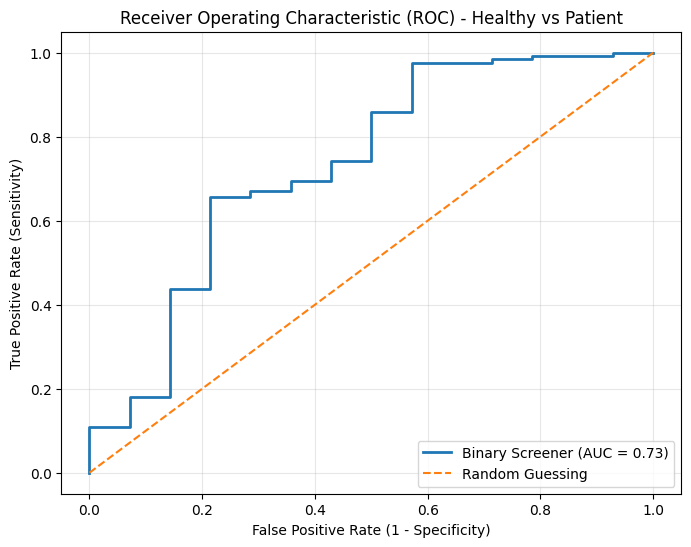

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Get the probabilities of the positive class (Patient = 1)
y_val_probs = nn_binary.predict_proba(X_val_selected)[:, 1]

# 2. Calculate False Positive Rate, True Positive Rate, and Thresholds
fpr, tpr, thresholds = roc_curve(y_val_binary, y_val_probs)

# 3. Calculate the Area Under the Curve (AUC)
# An AUC of 0.5 is random guessing, 1.0 is a perfect model
roc_auc = auc(fpr, tpr)

# 4. Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Binary Screener (AUC = {roc_auc:.2f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guessing') # Diagonal baseline

plt.title('Receiver Operating Characteristic (ROC) - Healthy vs Patient')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()